## Question 1

In [2]:
import pandas as pd 
import numpy as np 

In [5]:
df = pd.read_csv('HW2//hospital_data.csv')
df.head(5)

,Hospital,Treatment,Recovery
0,0,0,0.81
1,1,1,0.64
2,1,0,0.50
3,0,0,1.00
4,0,0,0.90


### Q 1.1

In [7]:
overall = df.groupby("Treatment")["Recovery"].mean()

print("E[R|T=1] =", overall[1])
print("E[R|T=0] =", overall[0])
print("Difference =", overall[1] - overall[0])

E[R|T=1] = 0.7070931563286793
E[R|T=0] = 0.7722464926300835
Difference = -0.06515333630140419


**Answer**: 

Based on the overall observational averages, E[R|T=0] > E[R|T=1].

T=0 (the old standard treatment) appears better.

### Q 1.2

In [9]:
grouped_h = df.groupby(["Hospital", "Treatment"])["Recovery"].mean().unstack()
print(grouped_h)

Treatment         0         1
Hospital                     
0          0.804058  0.848616
1          0.570209  0.650819


In [10]:
within_diff = grouped_h[1] - grouped_h[0]
print(within_diff)

Hospital
0    0.044559
1    0.080610
dtype: float64


In [11]:
grouped_h[1]

Hospital
0    0.848616
1    0.650819
Name: 1, dtype: float64

**Answer**:

Although the overall observational comparison in Q1.1 suggested that the old treatment (T=0) performs better, the stratified comparison shows that within each hospital, the new treatment (T=1) yields a higher average recovery. 

### Q 1.3

In [13]:
# hospital proportions
proportion_h = df["Hospital"].value_counts(normalize=True).sort_index()
print(proportion_h)

# mean recovery by hospital and treatment
grouped_h = df.groupby(["Hospital", "Treatment"])["Recovery"].mean().unstack()
print(grouped_h)

# adjustment formula
ER_do_t1 = grouped_h.loc[0, 1] * proportion_h[0] + grouped_h.loc[1, 1] * proportion_h[1]
ER_do_t0 = grouped_h.loc[0, 0] * proportion_h[0] + grouped_h.loc[1, 0] * proportion_h[1]

ACE = ER_do_t1 - ER_do_t0

print("E[R|do(T=1)] =", ER_do_t1)
print("E[R|do(T=0)] =", ER_do_t0)
print("ACE =", ACE)

Hospital
0    0.6108
1    0.3892
Name: proportion, dtype: float64
Treatment         0         1
Hospital                     
0          0.804058  0.848616
1          0.570209  0.650819
E[R|do(T=1)] = 0.7716335367604328
E[R|do(T=0)] = 0.713043648995999
ACE = 0.058589887764433746


**Answer**:

The only backdoor path from T to R is T←H→R, so the valid adjustment set is {H}.

Using the adjustment formula, we obtain:

E[R∣do(T=t)]= h∈{0,1}∑ ​E[R∣T=t,H=h]P(H=h),

ACE=E[R∣do(T=1)]−E[R∣do(T=0)] ≈ 0.059

### Q 1.4

**Answer**:

After controlling for hospital assignment H, the new treatment (T=1) yields a higher expected recovery, with an estimated ACE ≈ 0.059. Therefore, the new treatment is causally better than the old treatment on average.


This conclusion differs from the initial observational comparison because hospital assignment is a confounder. In the DAG, H affects both treatment choice and recovery, creating the backdoor path T←H→R. As a result, the overall difference E[R∣T=1]−E[R∣T=0] is not a causal effect. Once we adjust for H, this confounding is removed, and the estimated effect reflects the true causal impact of the treatment.

## Question 2

### Q 2.3

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# 1. Generate one dataset
def generate_data(n=150, seed=None):
    rng = np.random.default_rng(seed)

    F = rng.uniform(0, 0.45, n)
    S = rng.uniform(0, 0.45, n)

    eps_M = rng.uniform(-0.18, 0.18, n)
    eps_P = rng.uniform(-0.18, 0.18, n)
    eps_X = rng.uniform(-0.35, 0.35, n)
    eps_Y = rng.uniform(-0.25, 0.25, n)

    M = 0.8 * F + eps_M
    P = 0.7 * F + 0.7 * S + eps_P
    X = ((0.8 * P + 0.8 * M + eps_X) > 0.32).astype(int)
    Y = 2 * X + 1.2 * P + 1.2 * M + 0.8 * S + eps_Y

    return pd.DataFrame({
        "F": F, "S": S, "M": M, "P": P, "X": X, "Y": Y
    })

In [16]:
def discretize_column(x, width=0.1):
    return np.floor(x / width) * width

In [26]:
def estimate_ate_adjustment(df, z_vars, width=0.1):
    data = df.copy()

    for z in z_vars:
        data[z + "_bin"] = np.floor(data[z] / width) * width

    bin_cols = [z + "_bin" for z in z_vars]
    grouped = data.groupby(bin_cols)

    weighted_sum = 0.0
    used_mass = 0.0

    for _, g in grouped:
        p_z = len(g) / len(data)

        g1 = g[g["X"] == 1]
        g0 = g[g["X"] == 0]

        if len(g1) == 0 or len(g0) == 0:
            continue

        ey1 = g1["Y"].mean()
        ey0 = g0["Y"].mean()

        weighted_sum += (ey1 - ey0) * p_z
        used_mass += p_z

    if used_mass == 0:
        return np.nan

    return weighted_sum / used_mass

In [28]:
ate_z1 = []
ate_z2 = []

for rep in range(100):
    df = generate_data(n=150, seed=rep)

    ate1 = estimate_ate_adjustment(df, z_vars=["P", "M"], width=0.1)
    ate2 = estimate_ate_adjustment(df, z_vars=["P", "M", "F", "S"], width=0.1)

    ate_z1.append(ate1)
    ate_z2.append(ate2)

ate_z1 = np.array(ate_z1)
ate_z2 = np.array(ate_z2)

print("Z1 mean:", ate_z1.mean(), "std:", ate_z1.std())
print("Z2 mean:", ate_z2.mean(), "std:", ate_z2.std())

Z1 mean: 2.0126859088263354 std: 0.043582338184914374
Z2 mean: 2.020067680856278 std: 0.08538915041059104


/var/folders/w4/skhfqvnd4gj2ffzy3j226d040000gn/T/ipykernel_55041/1950113407.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ate_z1, ate_z2], labels=["Z1 = {P,M}", "Z2 = {P,M,F,S}"])


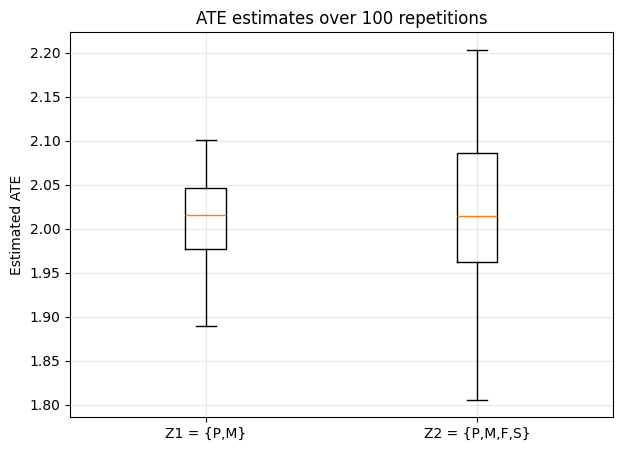

In [29]:
plt.figure(figsize=(7,5))
plt.boxplot([ate_z1, ate_z2], labels=["Z1 = {P,M}", "Z2 = {P,M,F,S}"])
plt.ylabel("Estimated ATE")
plt.title("ATE estimates over 100 repetitions")
plt.grid(True, alpha=0.3)
plt.show()

**Answer**：

The estimator based on Z1 is clearly more stable, whose standard deviation is about 0.044, compared with about 0.085 for Z2. And this difference is clearly visible with this sample size.

Thus, while both sets identify the causal effect, the smaller adjustment set Z1 performs better in finite samples. This is because discretizing the larger set Z2 creates many more strata, leading to sparser cells and noisier conditional mean estimates.